# FAPE, Cross-Domain Fairness Comparison

ThresholdOptimizer results across the eight evaluations. The script compares gradient boosting's fairness intervention results for COMPAS (criminal justice, race), Folktables (income prediction, race), Law School (bar passage, race), Lending Club (loan default, income band), Agricultural (SBA loan default, business type), FairGround (law_school_lequy sub-dataset, race), MEPS (healthcare utilization, race; it runs through the FairGround pipeline) and Student (Math, sex). Every DPD, EOD and accuracy value is read from `threshold_aggregation.RESULTS` and `MEPS_RESULTS`, so the figures cannot disagree with Table 2. Accuracy cost is left empty for Law School, Lending Club and Agricultural, whose intervention scripts report AUC rather than accuracy. The disparate impact ratio is shown only for the three domains that compute a fixed-pair ratio before and after the constraint; both lending domains predict default, so there a ratio above 1.0 is the adverse direction.

Code: `src/cross_domain_comparison.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from cross_domain_comparison import run_cross_domain_comparison

run_cross_domain_comparison();  # returns DOMAINS; the semicolon keeps Jupyter from echoing it

FAPE, Cross-Domain Fairness Comparison (gradient boosting)

--- Domain Summary ---
  COMPAS        DP improve: +33.4% | EO improve: +34.1% | ACC cost (DP): -0.001
  Folktables    DP improve: -23.5% | EO improve: +45.6% | ACC cost (DP): 0.016
  Law School    DP improve: +91.5% | EO improve: +98.7% | ACC cost (DP): n/a (AUC)
  Lending Club  DP improve: +25.0% | EO improve: +7.5% | ACC cost (DP): n/a (AUC)
  Agricultural  DP improve: -244.4% | EO improve: -142.5% | ACC cost (DP): n/a (AUC)
  FairGround    DP improve: +95.9% | EO improve: +96.9% | ACC cost (DP): 0.159
  MEPS          DP improve: +85.9% | EO improve: +30.4% | ACC cost (DP): 0.075
  Student       DP improve: +9.3% | EO improve: +63.7% | ACC cost (DP): 0.076

--- Key Cross-Domain Findings (computed) ---
  Largest GB DPD improvement: FairGround (+95.9%)
  Largest GB DPD worsening: Agricultural (-244.4%)
  Highest GB accuracy cost under DP: FairGround (0.159)
  Pairs with baseline DPD > 0.2 that improved: 9 of 14
  Pairs with b

  Fig 1 saved, cross_domain_dpd_comparison.png
  Fig 2 saved, cross_domain_eod_comparison.png


  Fig 3 saved, cross_domain_acc_fairness_scatter.png
  Fig 4 saved, cross_domain_dir_comparison.png


  Fig 5 saved, cross_domain_metrics_heatmap.png


  Fig 6 saved, cross_domain_improvement_ranking.png

--- Cross-Domain Comparison complete ---
  6 figures saved to figures/stage2/


## 1. DPD before and after the constraint

Gradient boosting's demographic parity difference at baseline and after the demographic parity constraint, by domain.

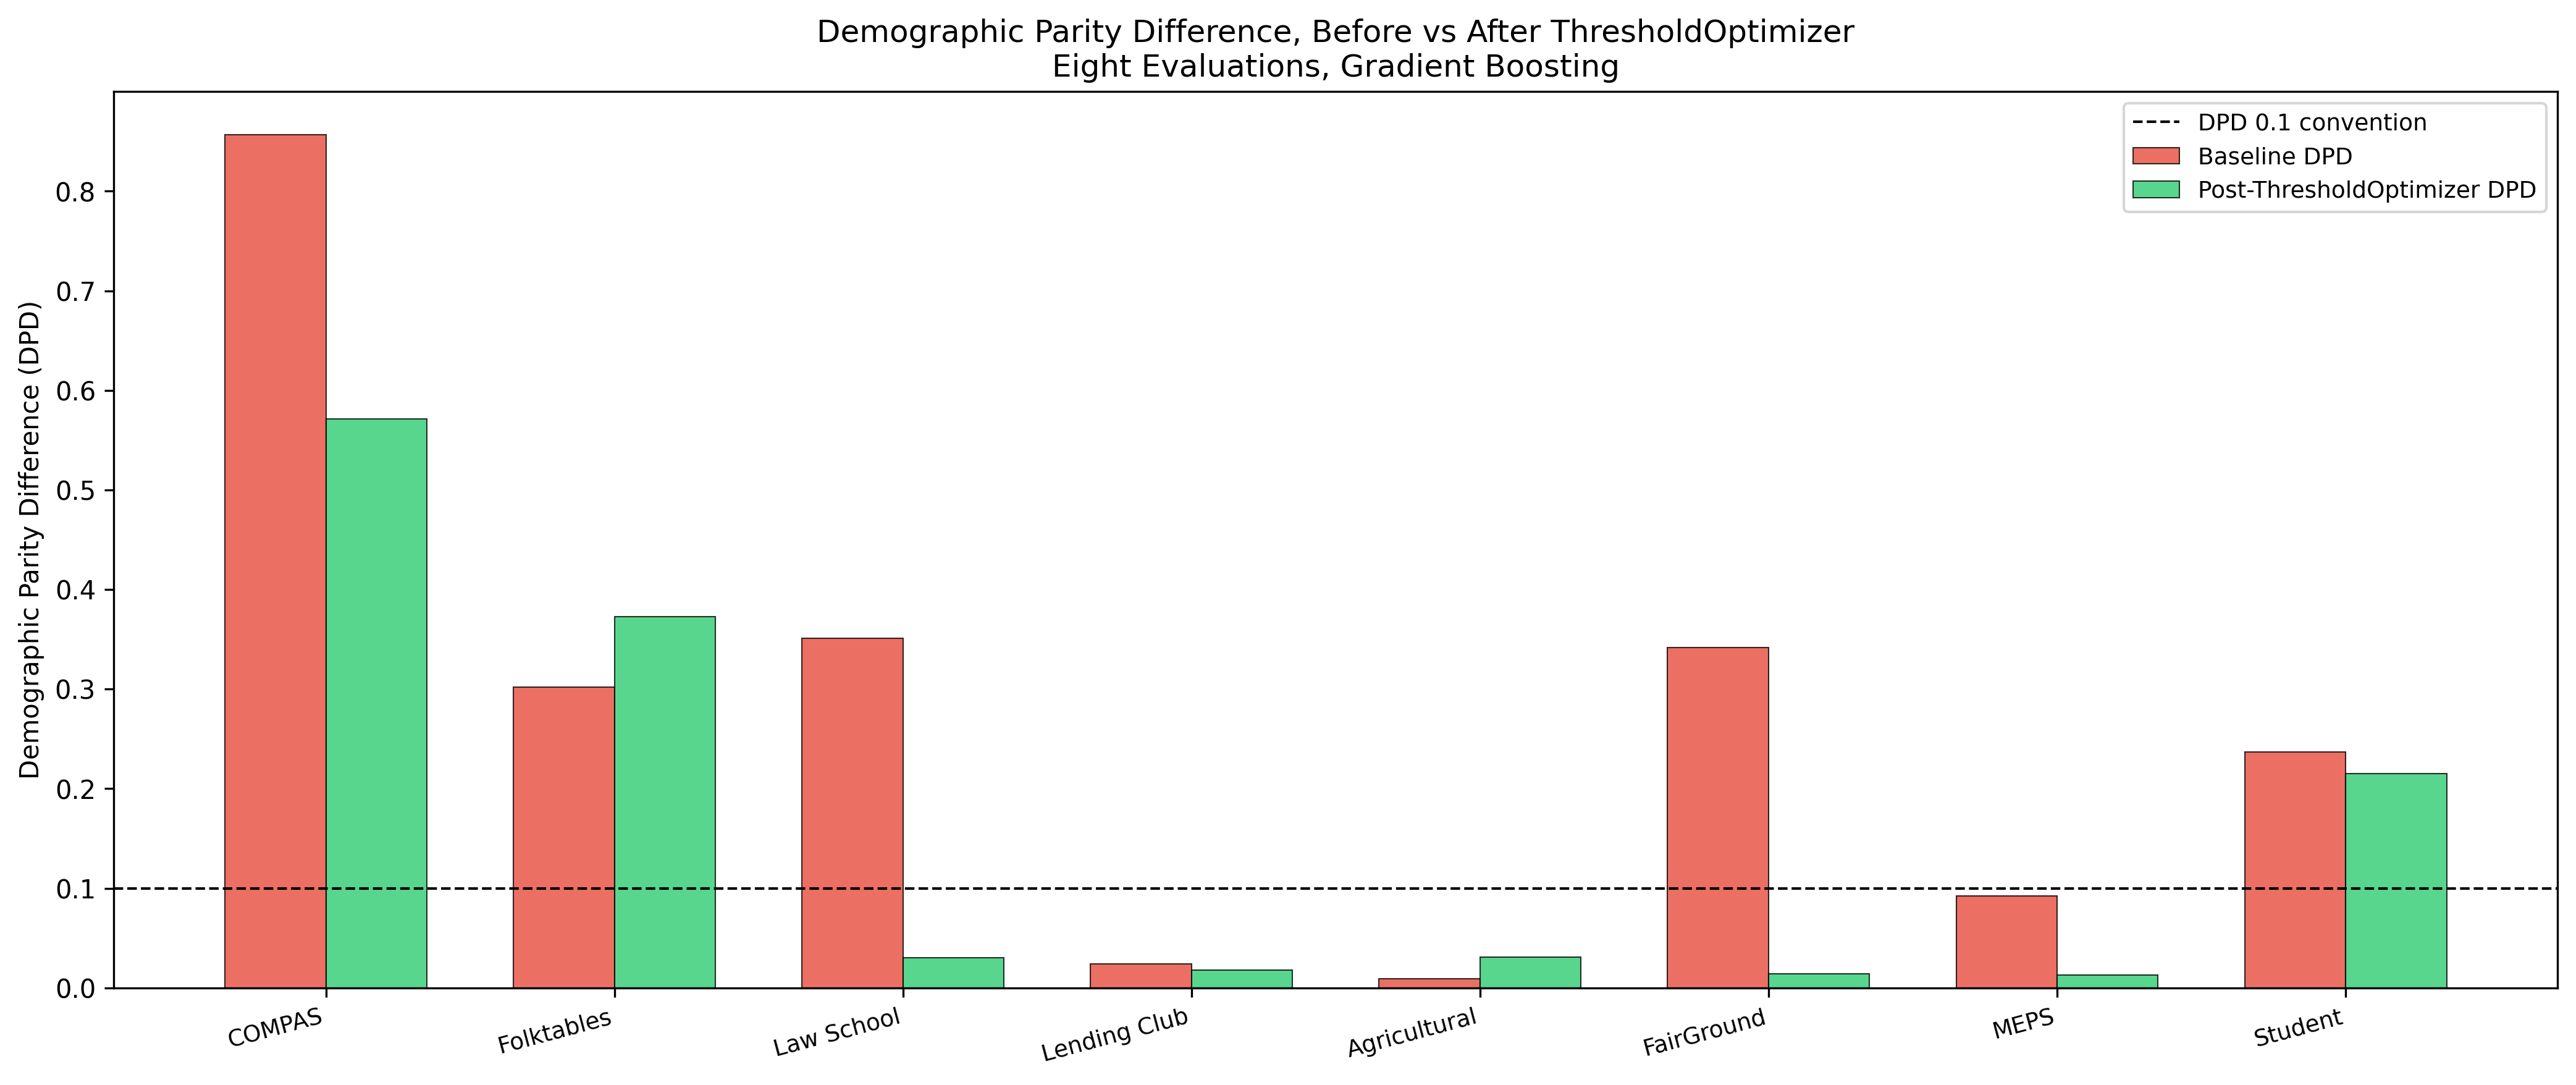

In [3]:
display(Image('figures/stage2/cross_domain_dpd_comparison.png'))

## 2. EOD before and after the constraint

Gradient boosting's equalized odds difference at baseline and after the equalized odds constraint, by domain.

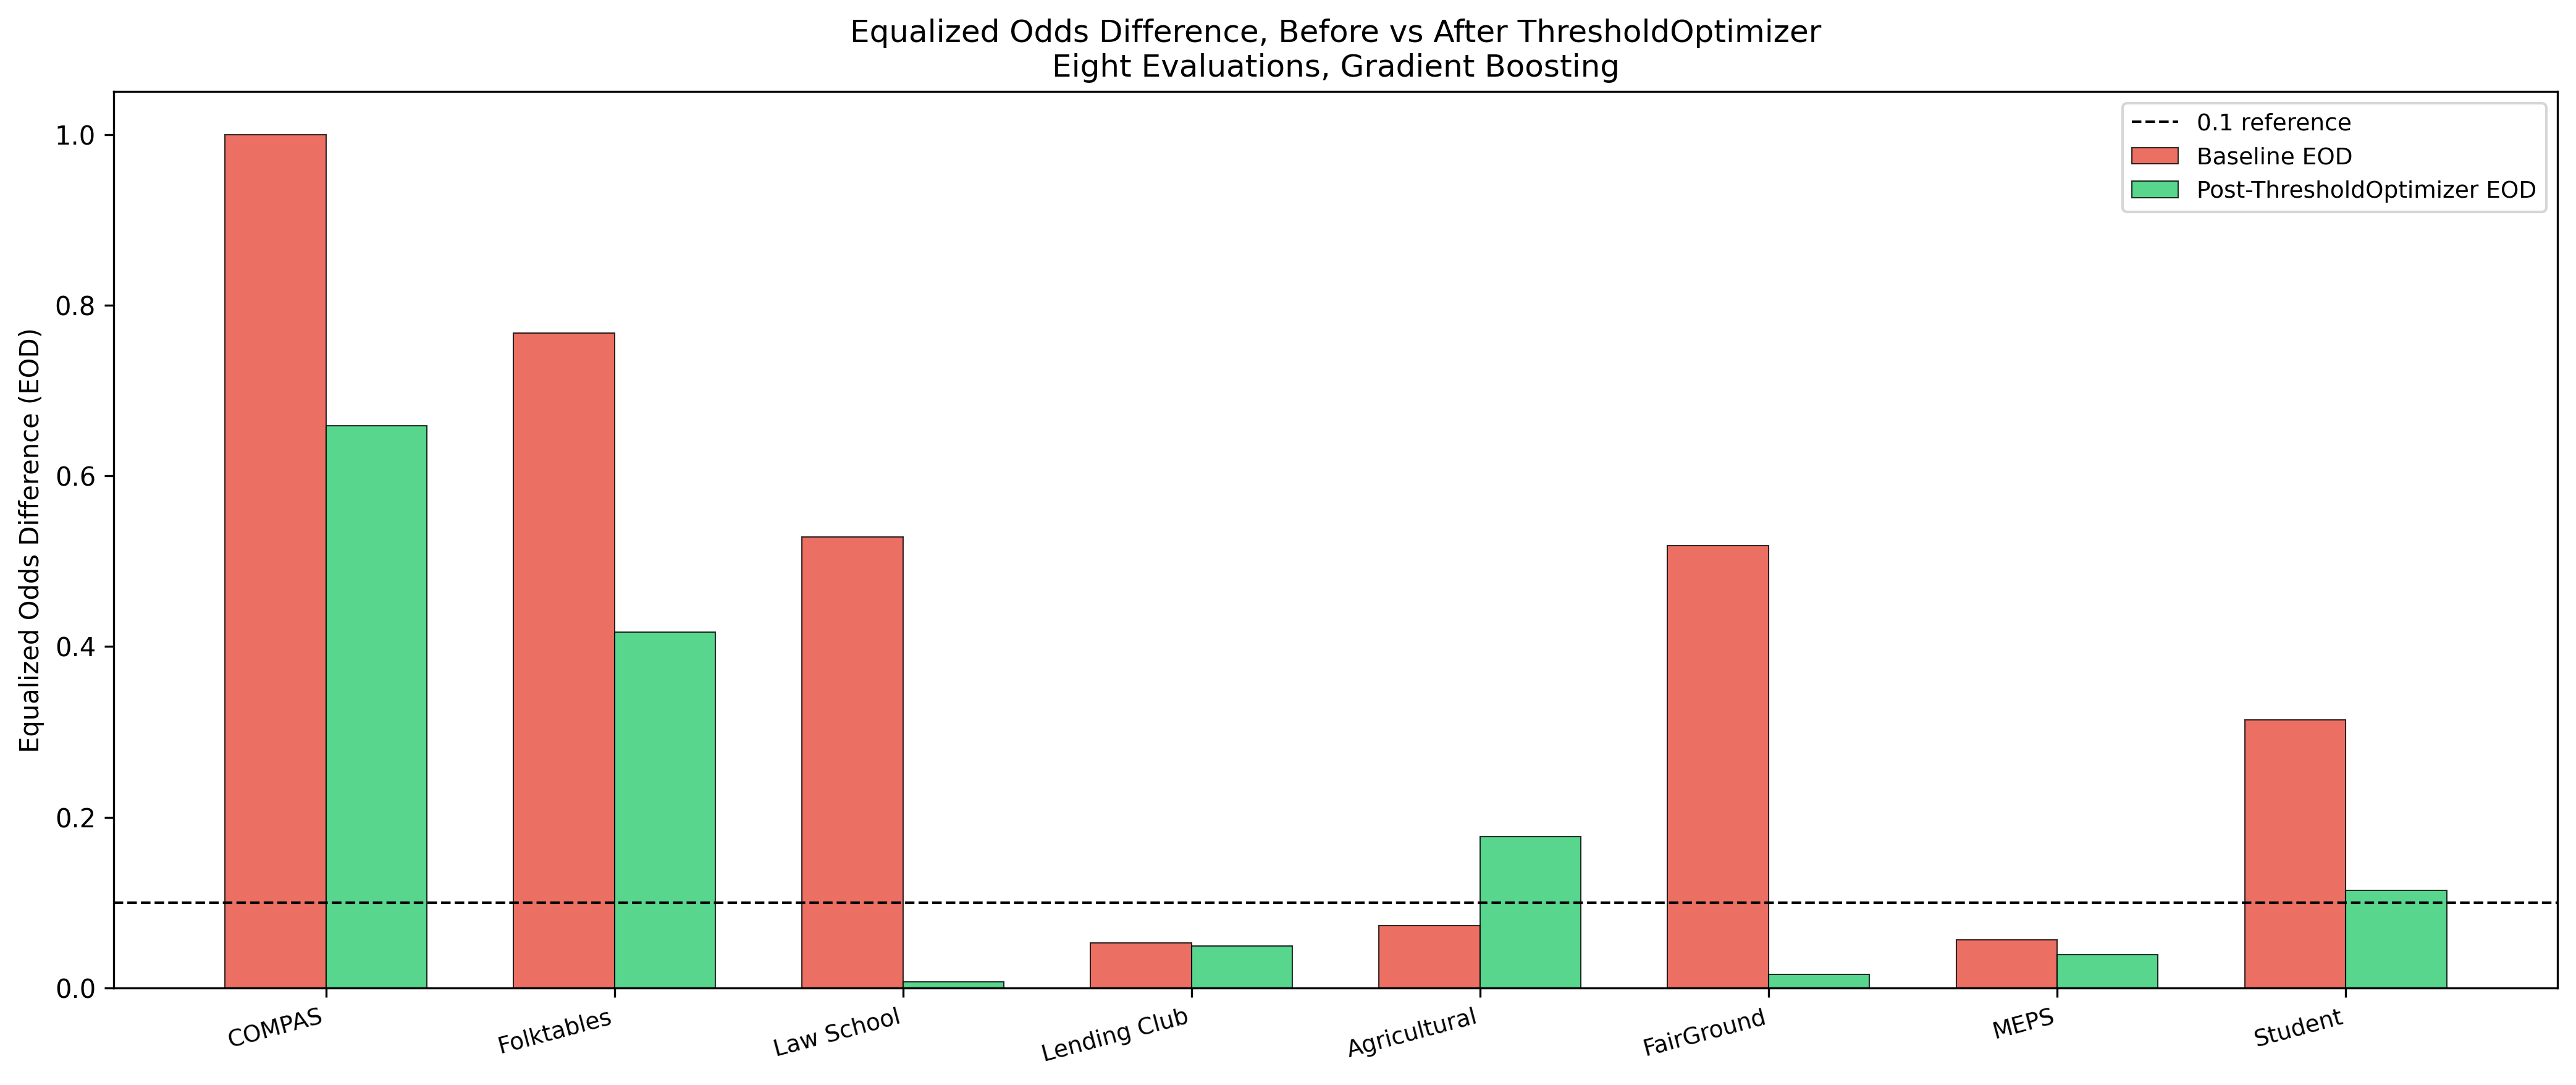

In [4]:
display(Image('figures/stage2/cross_domain_eod_comparison.png'))

## 3. Accuracy cost against fairness improvement

Accuracy cost plotted against the percentage change in DPD and in EOD, for the domains that report accuracy.

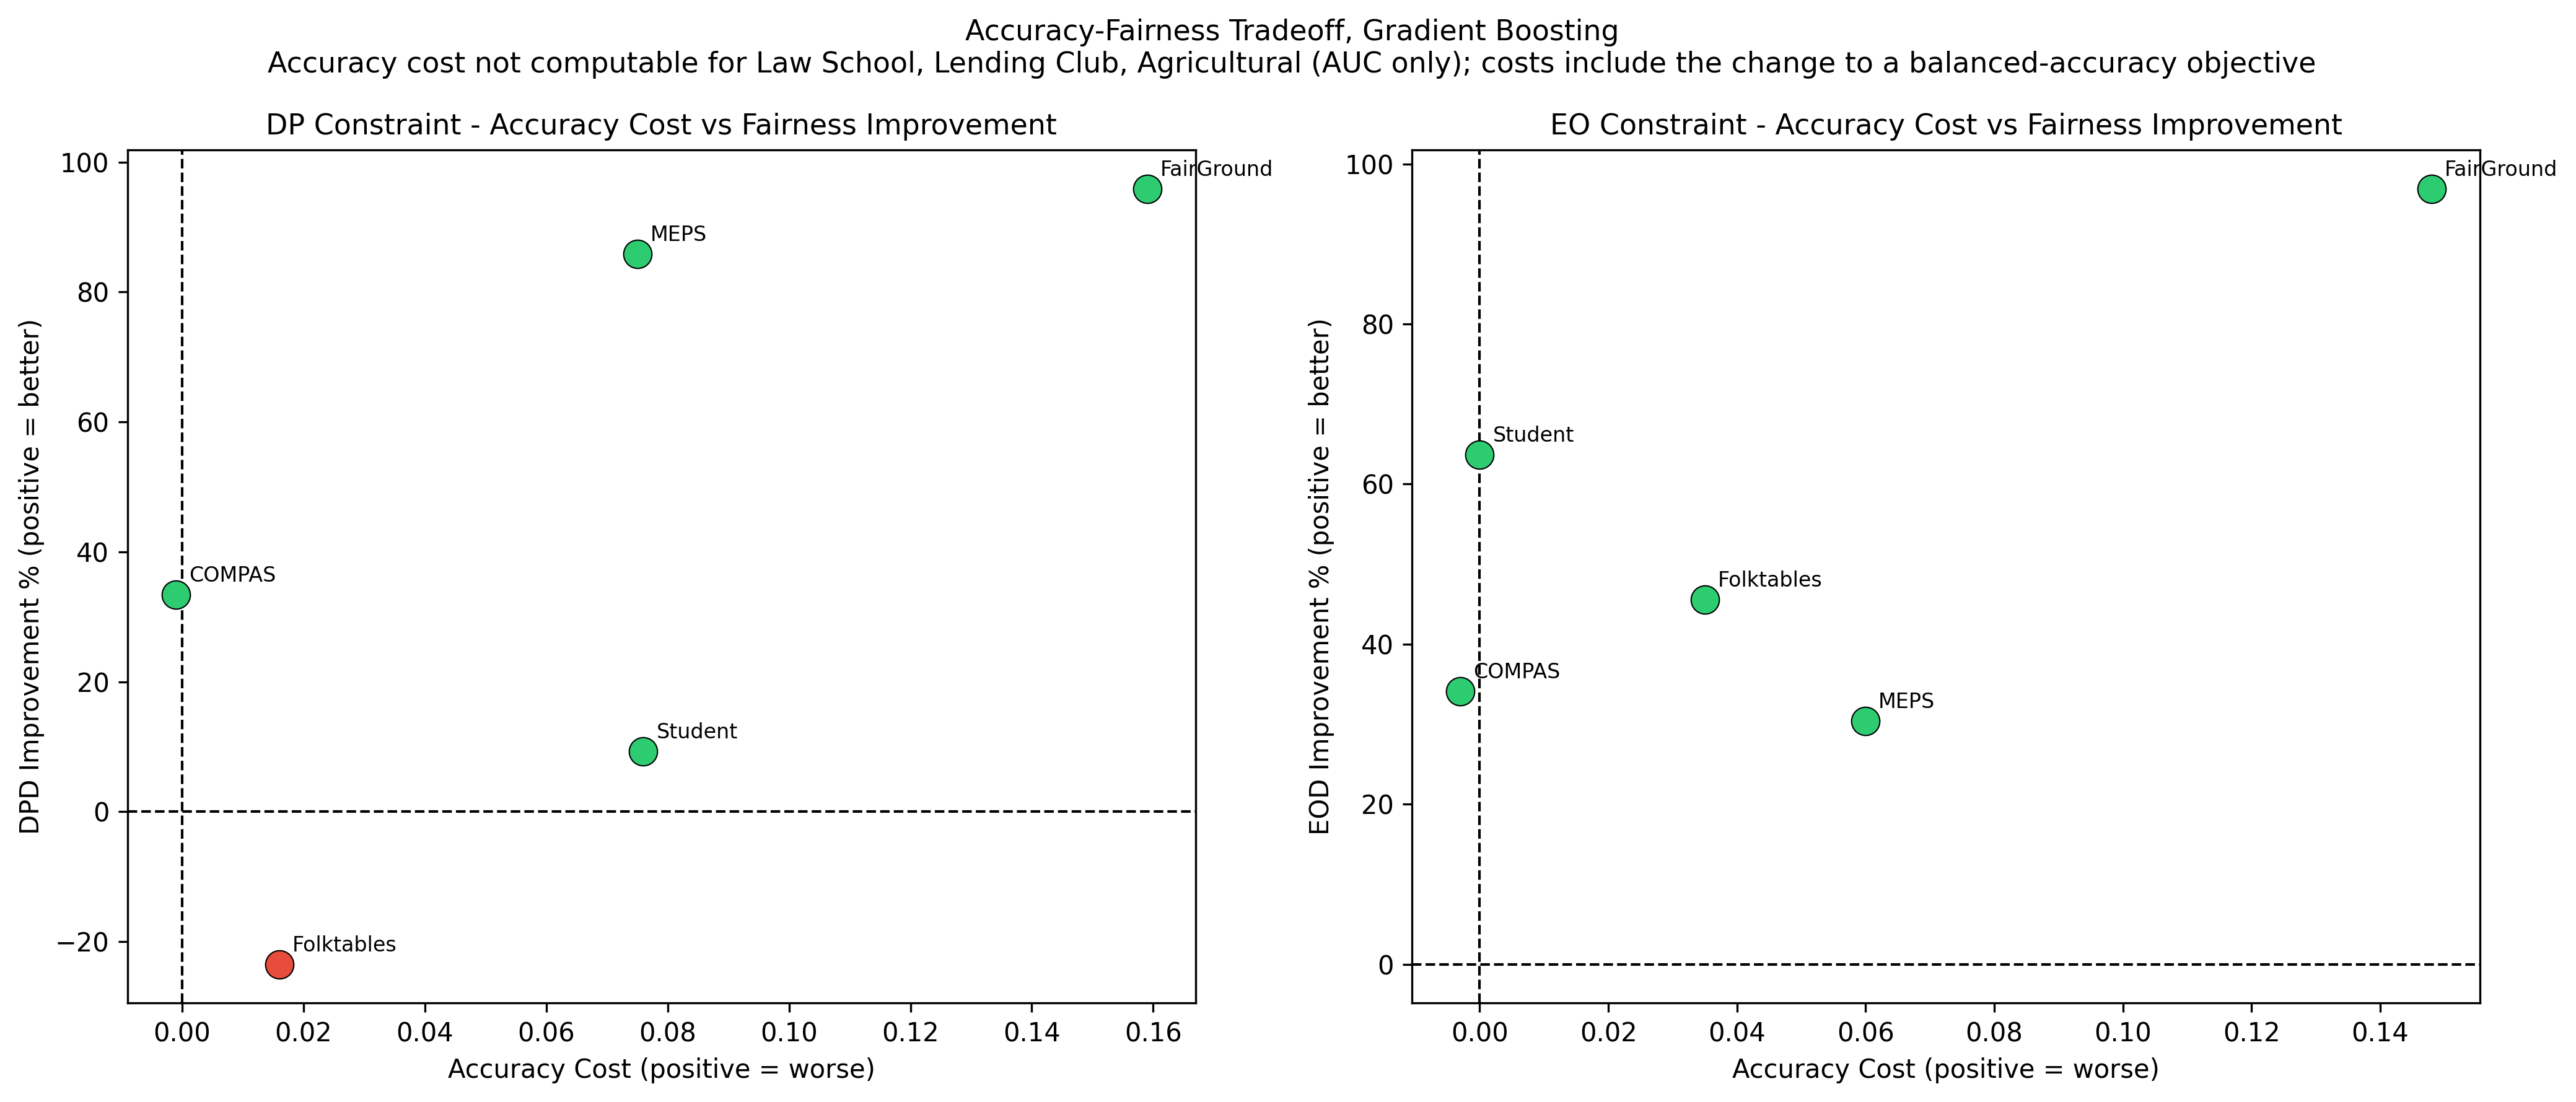

In [5]:
display(Image('figures/stage2/cross_domain_acc_fairness_scatter.png'))

## 4. Fixed-pair disparate impact ratio

Gradient boosting's fixed-pair disparate impact ratio before and after the demographic parity constraint, for the domains that compute one.

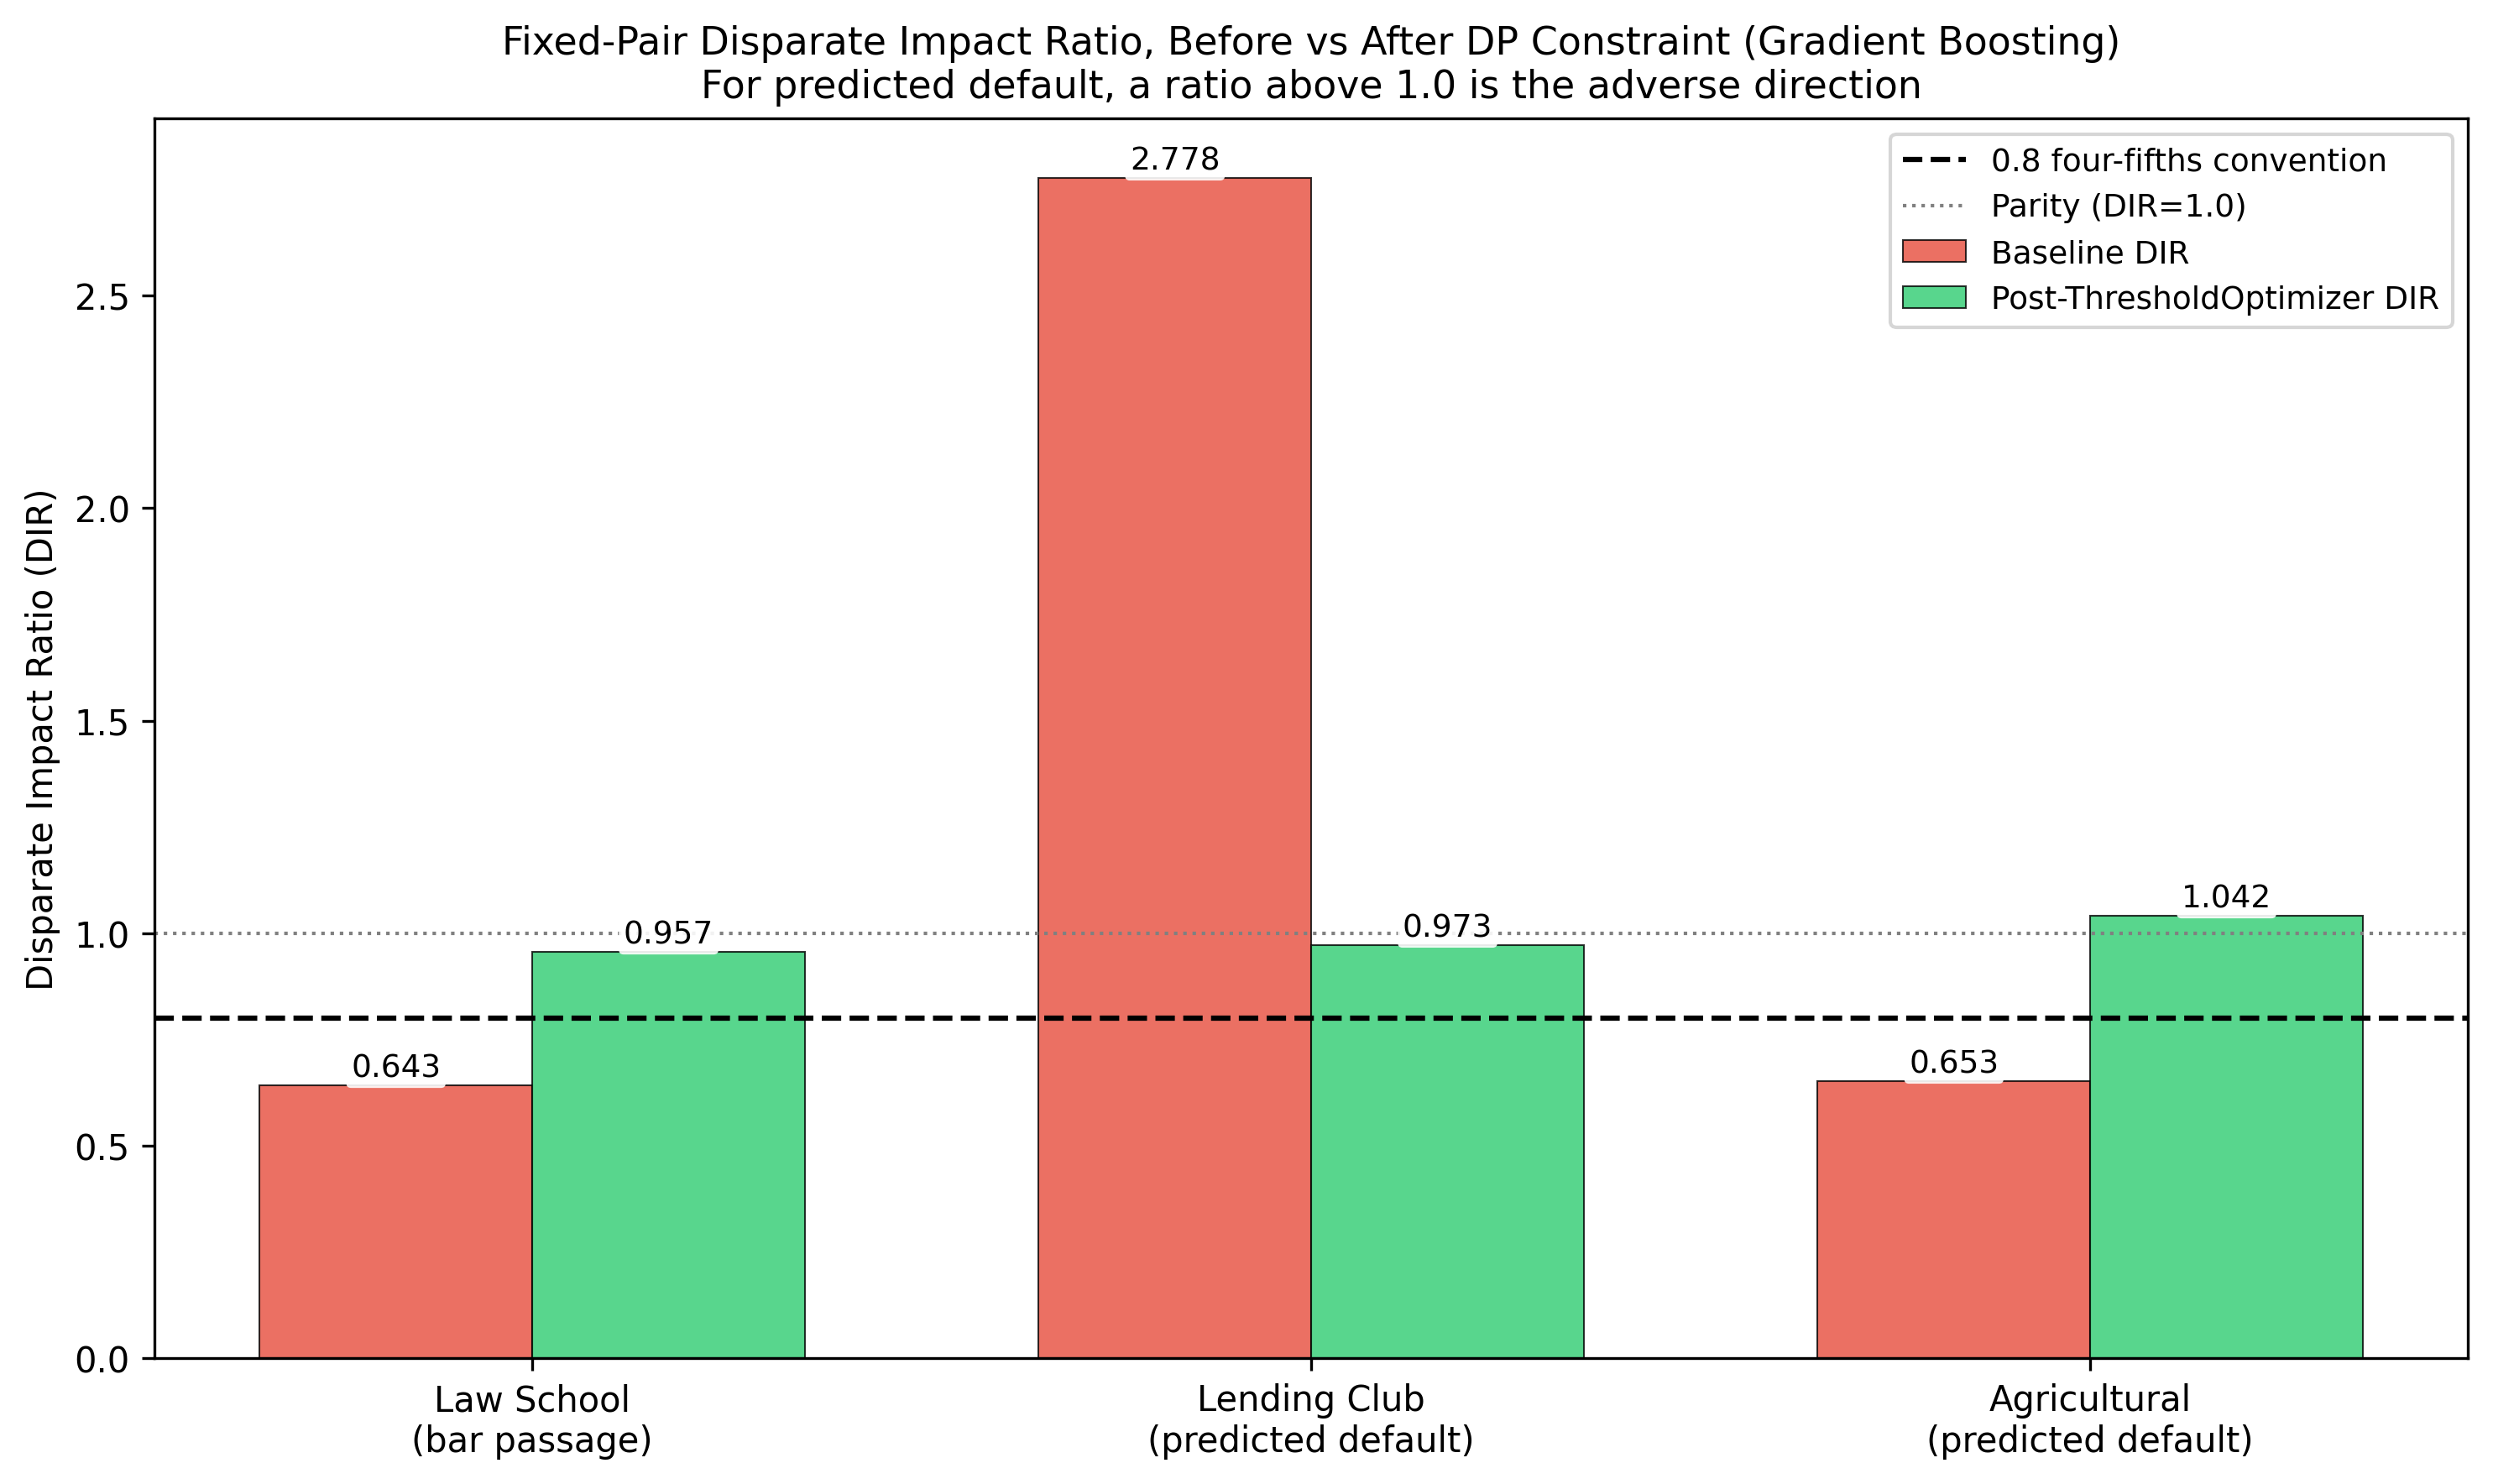

In [6]:
display(Image('figures/stage2/cross_domain_dir_comparison.png'))

## 5. Metrics summary heatmap

Baseline and post-constraint DPD and EOD, with accuracy cost, for each domain in one grid.

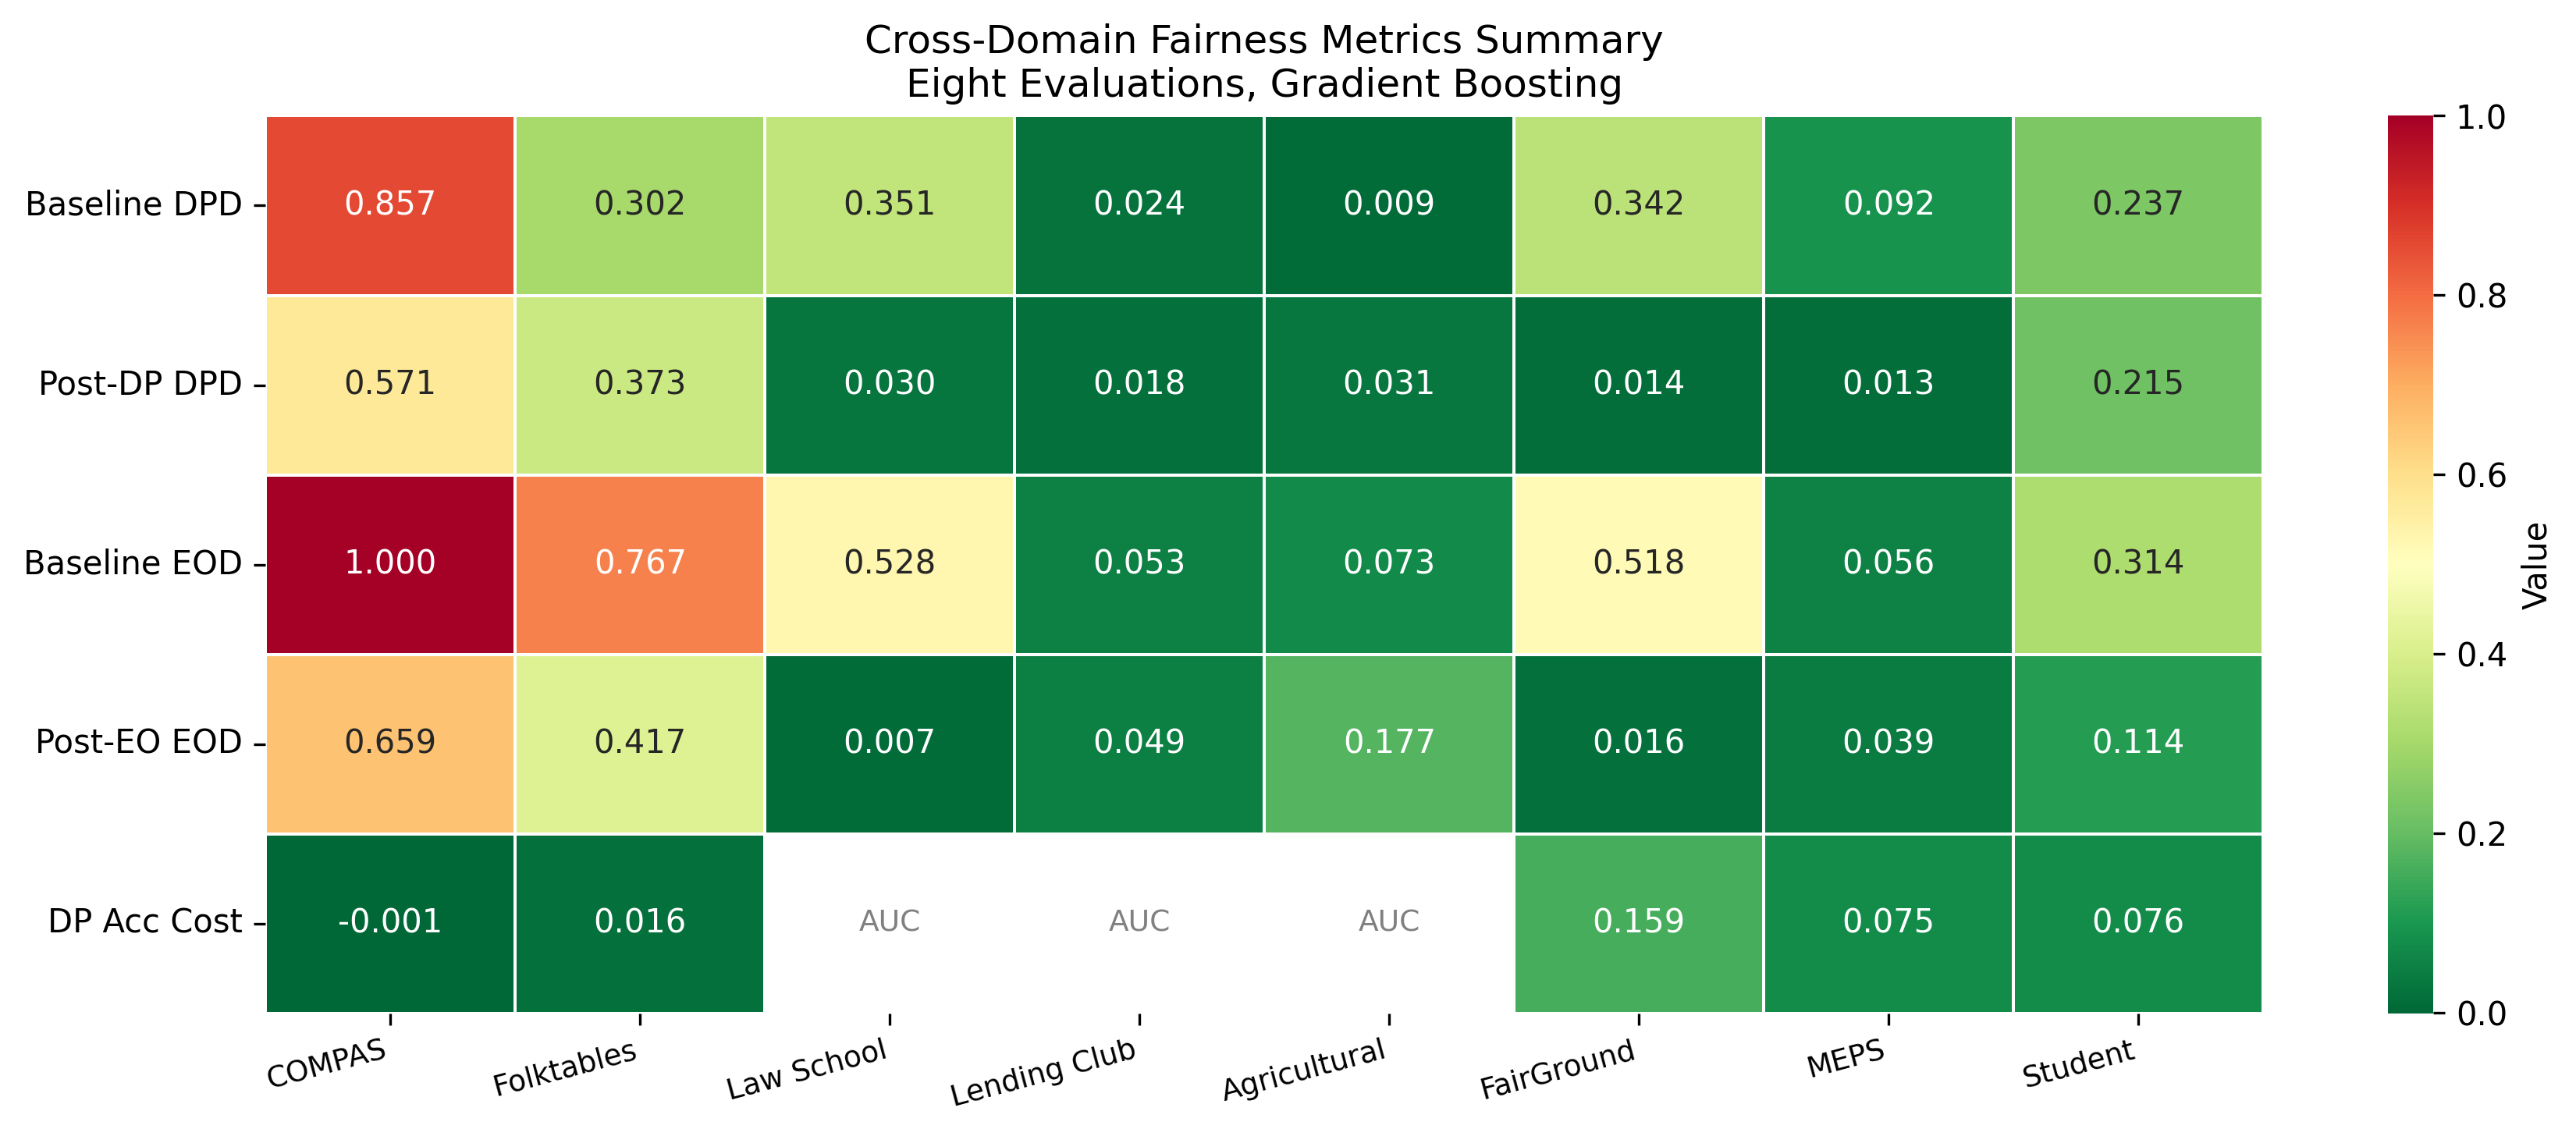

In [7]:
display(Image('figures/stage2/cross_domain_metrics_heatmap.png'))

## 6. Improvement ranking

Domains ordered by gradient boosting's percentage change under each constraint.

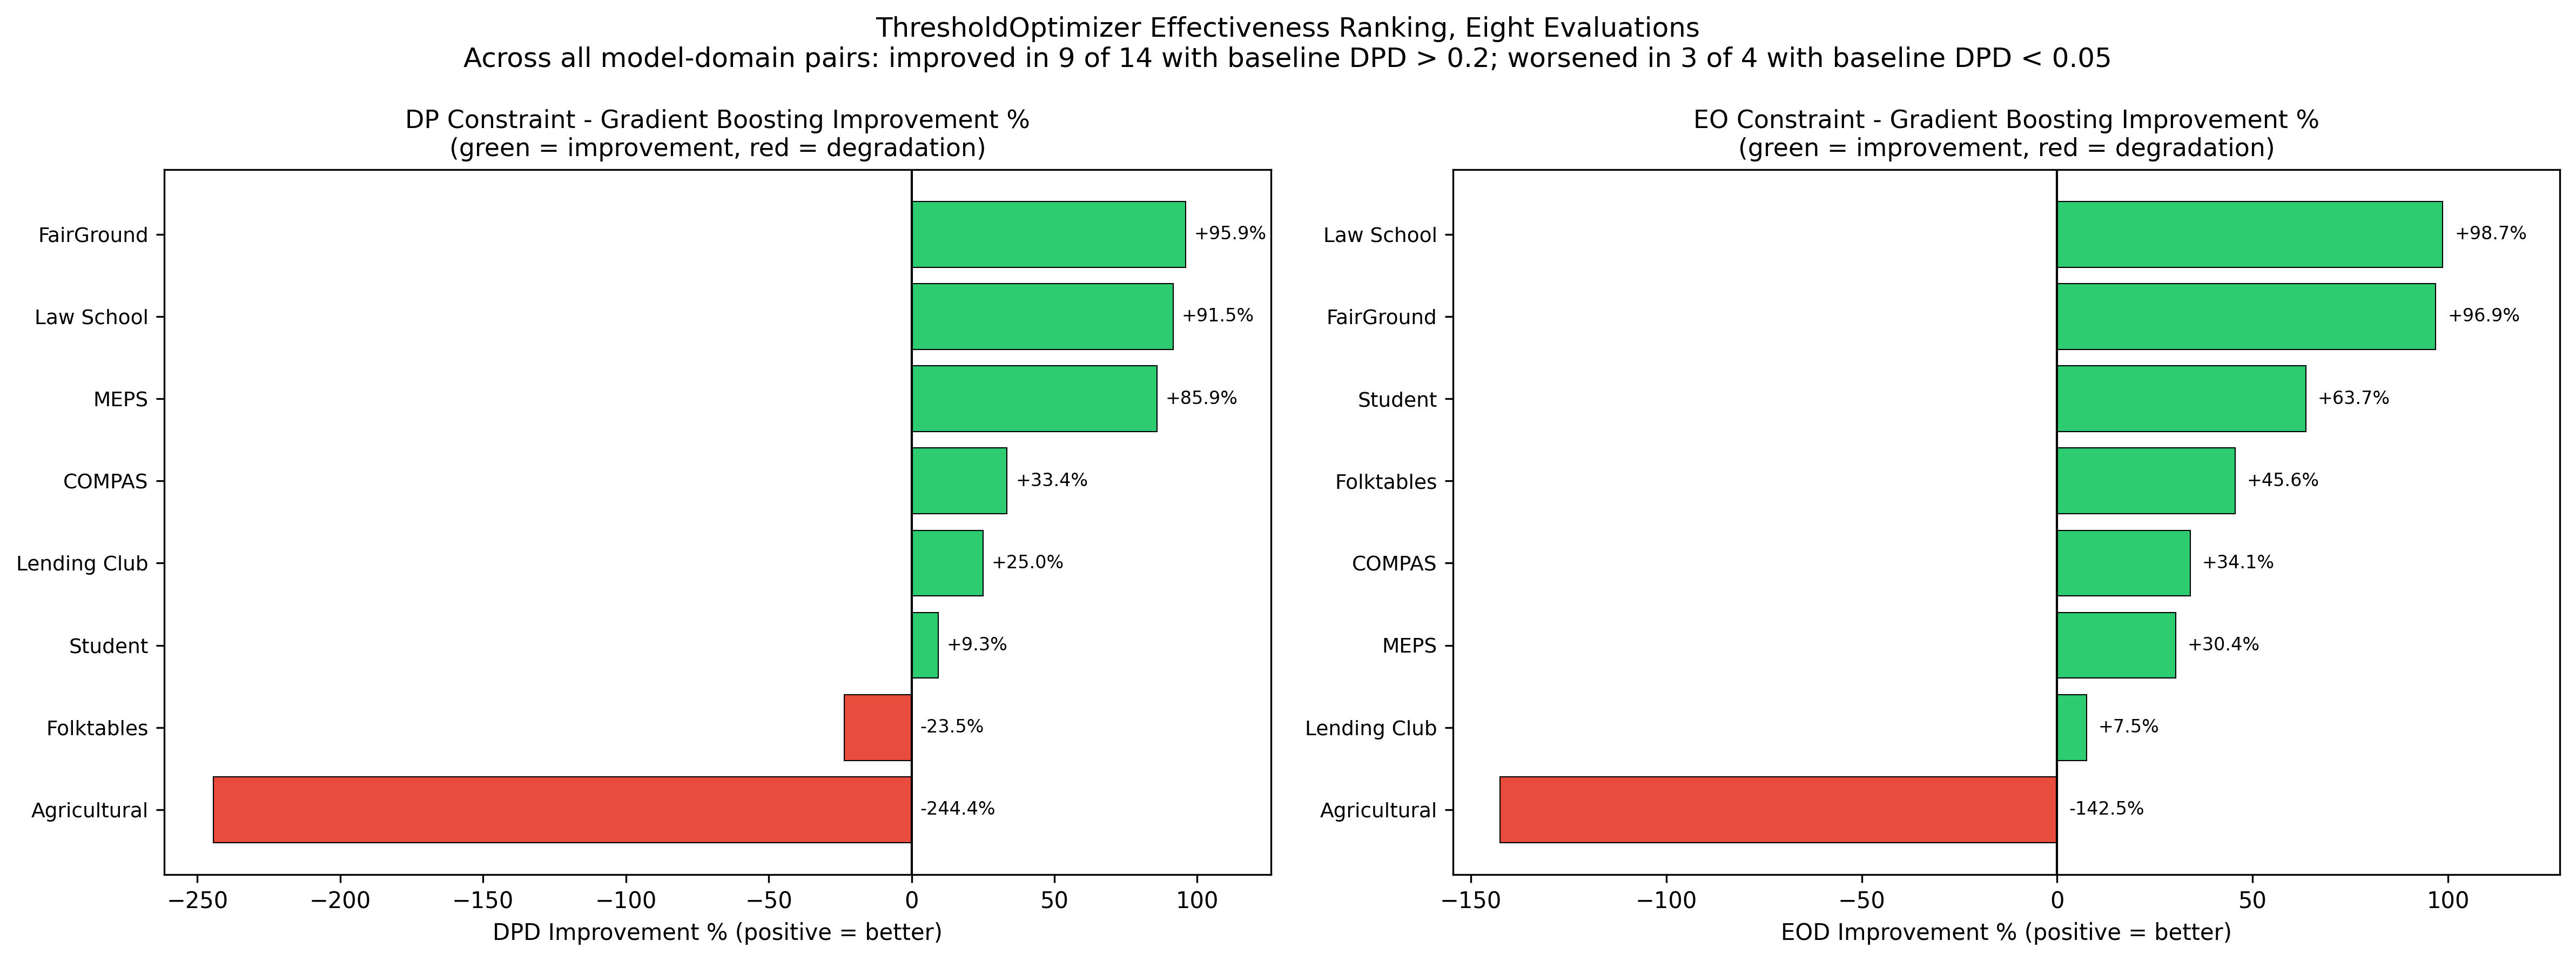

In [8]:
display(Image('figures/stage2/cross_domain_improvement_ranking.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.